<a href="https://colab.research.google.com/github/joseto02/Deep_learning/blob/main/Examen_Deep_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv("/content/IMDB Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
df.shape

(50000, 2)

In [ ]:
df.isnull().sum()

,0
review,0
sentiment,0


In [ ]:
df["sentiment"].value_counts()

,count
sentiment,
positive,25000
negative,25000


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(max_features=5000)

X = vectorizer.fit_transform(df["review"]).toarray()

In [ ]:
y = df["sentiment"].map({"positive": 1, "negative": 0})

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

In [ ]:
tf.random.set_seed(42)

# Modelo Baseline

Como punto de partida se implementa el mismo modelo utilizado en la evaluación anterior. Este servirá como referencia para comparar posteriormente las mejoras propuestas.

In [ ]:
model_baseline = keras.Sequential([
    layers.Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(8, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model_baseline.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
history_baseline = model_baseline.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.8612 - loss: 0.3497 - val_accuracy: 0.8590 - val_loss: 0.3553
Epoch 2/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9074 - loss: 0.2445 - val_accuracy: 0.8675 - val_loss: 0.3429
Epoch 3/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9201 - loss: 0.2099 - val_accuracy: 0.8727 - val_loss: 0.3395
Epoch 4/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9326 - loss: 0.1794 - val_accuracy: 0.8741 - val_loss: 0.3533
Epoch 5/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9428 - loss: 0.1529 - val_accuracy: 0.8717 - val_loss: 0.3878
Epoch 6/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9531 - loss: 0.1290 - val_accuracy: 0.8658 - val_loss: 0.4217
Epoch 7/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9616 - loss: 0.1059 - val_accuracy: 0.8646 - val_loss: 0.4717
Epoch 8/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9681 - loss: 0.0909 - 

In [ ]:
loss_baseline, acc_baseline = model_baseline.evaluate(
    X_test,
    y_test,
    verbose=0
)

print(f"Accuracy Baseline: {acc_baseline:.4f}")
print(f"Loss Baseline: {loss_baseline:.4f}")

Accuracy Baseline: 0.8652
Loss Baseline: 1.0940


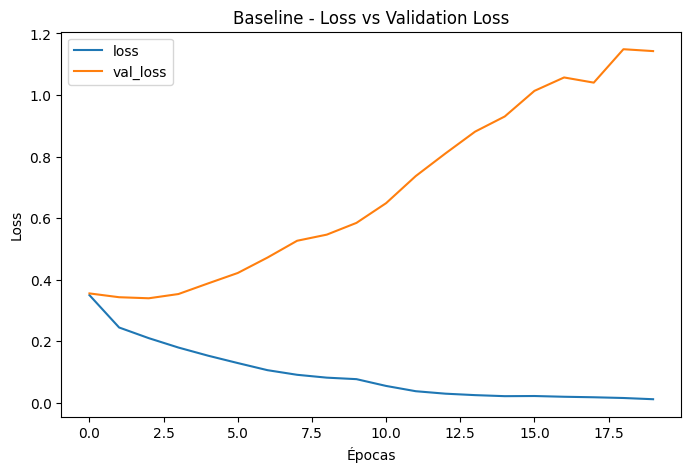

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history_baseline.history['loss'], label='loss')
plt.plot(history_baseline.history['val_loss'], label='val_loss')

plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.title('Baseline - Loss vs Validation Loss')
plt.legend()

plt.show()

# Modelo Mejorado

Se propone un modelo mejorado con cambios en arquitectura, regularización y entrenamiento.

A nivel de arquitectura, se aumenta moderadamente la capacidad del modelo agregando una capa oculta adicional. El objetivo es permitir que la red aprenda patrones más complejos en las reseñas.

Además, se incorpora Dropout para reducir el sobreajuste, apagando aleatoriamente una fracción de neuronas durante el entrenamiento. Finalmente, se utiliza Early Stopping para detener el entrenamiento cuando la pérdida de validación deja de mejorar.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

model_mejorado = keras.Sequential([
    layers.Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dropout(0.5),

    layers.Dense(16, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(8, activation='relu'),

    layers.Dense(1, activation='sigmoid')
])

model_mejorado.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [ ]:
history_mejorado = model_mejorado.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.7642 - loss: 0.4902 - val_accuracy: 0.8755 - val_loss: 0.3057
Epoch 2/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8780 - loss: 0.3094 - val_accuracy: 0.8826 - val_loss: 0.2835
Epoch 3/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9003 - loss: 0.2595 - val_accuracy: 0.8894 - val_loss: 0.2842
Epoch 4/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9104 - loss: 0.2316 - val_accuracy: 0.8854 - val_loss: 0.2953
Epoch 5/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9204 - loss: 0.2081 - val_accuracy: 0.8798 - val_loss: 0.3136
Epoch 6/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9205 - loss: 0.1968 - val_accuracy: 0.8831 - val_loss: 0.3272
Epoch 7/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9282 - loss: 0.1807 - val_accuracy: 0.8829 - val_loss: 0.3290


In [ ]:
loss_mejorado, acc_mejorado = model_mejorado.evaluate(
    X_test,
    y_test,
    verbose=0
)

print(f"Accuracy Modelo Mejorado: {acc_mejorado:.4f}")
print(f"Loss Modelo Mejorado: {loss_mejorado:.4f}")

Accuracy Modelo Mejorado: 0.8870
Loss Modelo Mejorado: 0.2687


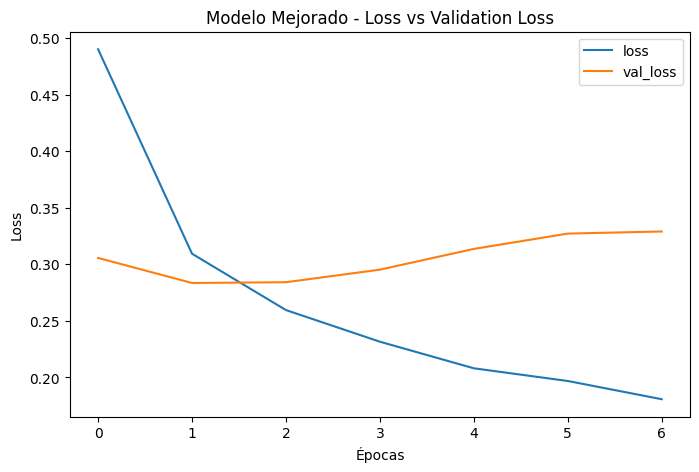

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history_mejorado.history["loss"], label="loss")
plt.plot(history_mejorado.history["val_loss"], label="val_loss")

plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.title("Modelo Mejorado - Loss vs Validation Loss")
plt.legend()

plt.show()

In [ ]:
import pandas as pd

comparacion = pd.DataFrame({
    "Modelo": ["Baseline", "Mejorado"],
    "Accuracy": [acc_baseline, acc_mejorado],
    "Loss": [loss_baseline, loss_mejorado]
})

comparacion

,Modelo,Accuracy,Loss
0,Baseline,0.8652,1.094011
1,Mejorado,0.8870,0.268722
